<a href="https://colab.research.google.com/github/laasika25/Deforestation_Detection/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [2]:
df1 = pd.read_csv('DataSet_2021.csv')
df2 = pd.read_csv('DataSet_2022.csv')
df3 = pd.read_csv('DataSet_2023.csv')

In [3]:
df = pd.concat([df1, df2, df3], ignore_index=True)
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,28.0993,96.9983,303.0,1.1,1.1,2021-01-01,409,Terra,MODIS,44,6.03,292.6,8.6,D,0
1,30.0420,79.6492,301.8,1.4,1.2,2021-01-01,547,Terra,MODIS,37,6.03,287.4,9.0,D,0
2,30.0879,78.8579,300.2,1.3,1.1,2021-01-01,547,Terra,MODIS,8,6.03,286.5,5.4,D,0
3,30.0408,80.0501,302.0,1.5,1.2,2021-01-01,547,Terra,MODIS,46,6.03,287.7,10.7,D,0
4,30.6565,78.9668,300.9,1.3,1.1,2021-01-01,547,Terra,MODIS,43,6.03,287.6,9.0,D,0


In [4]:
for col in df.columns:
  if df[col].dtype == 'object':
    print(f"Column: {col}")
    print(f"Unique values: {df[col].unique()}")
    print(f"Number of unique values: {df[col].nunique()}")
    print("-" * 50)

Column: acq_date
Unique values: ['2021-01-01' '2021-01-02' '2021-01-03' ... '2023-12-29' '2023-12-30'
 '2023-12-31']
Number of unique values: 1088
--------------------------------------------------
Column: satellite
Unique values: ['Terra' 'Aqua']
Number of unique values: 2
--------------------------------------------------
Column: instrument
Unique values: ['MODIS']
Number of unique values: 1
--------------------------------------------------
Column: daynight
Unique values: ['D' 'N']
Number of unique values: 2
--------------------------------------------------


In [8]:
df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,28.0993,96.9983,303.0,1.1,1.1,2021-01-01,409,Terra,MODIS,44,6.03,292.6,8.6,D,0
1,30.0420,79.6492,301.8,1.4,1.2,2021-01-01,547,Terra,MODIS,37,6.03,287.4,9.0,D,0
2,30.0879,78.8579,300.2,1.3,1.1,2021-01-01,547,Terra,MODIS,8,6.03,286.5,5.4,D,0
3,30.0408,80.0501,302.0,1.5,1.2,2021-01-01,547,Terra,MODIS,46,6.03,287.7,10.7,D,0
4,30.6565,78.9668,300.9,1.3,1.1,2021-01-01,547,Terra,MODIS,43,6.03,287.6,9.0,D,0


In [9]:
df.type.value_counts()

,count
type,
0,257625
2,13550
3,42


In [10]:
categorical_cols = df.select_dtypes(include='object').columns

In [11]:
categorical_cols_to_encode = ['daynight', 'satellite', 'instrument']

df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

In [12]:
df_encoded.head(50)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,confidence,version,bright_t31,frp,type,daynight_N,satellite_Terra
0,28.0993,96.9983,303.0,1.1,1.1,2021-01-01,409,44,6.03,292.6,8.6,0,False,True
1,30.0420,79.6492,301.8,1.4,1.2,2021-01-01,547,37,6.03,287.4,9.0,0,False,True
2,30.0879,78.8579,300.2,1.3,1.1,2021-01-01,547,8,6.03,286.5,5.4,0,False,True
3,30.0408,80.0501,302.0,1.5,1.2,2021-01-01,547,46,6.03,287.7,10.7,0,False,True
4,30.6565,78.9668,300.9,1.3,1.1,2021-01-01,547,43,6.03,287.6,9.0,0,False,True
5,31.4738,77.8117,303.6,1.1,1.0,2021-01-01,547,56,6.03,280.4,9.5,0,False,True
6,31.4366,76.8988,300.5,1.0,1.0,2021-01-01,547,36,6.03,287.2,5.3,0,False,True
7,29.5369,79.4559,300.3,1.4,1.2,2021-01-01,547,33,6.03,289.7,6.3,0,False,True
8,30.5665,79.5317,305.9,1.4,1.2,2021-01-01,547,23,6.03,292.8,11.4,0,False,True
9,31.2932,77.2750,301.4,1.1,1.0,2021-01-01,547,35,6.03,290.2,4.3,0,False,True


In [13]:
scaler = StandardScaler()
numerical_cols_to_scale = ['brightness', 'scan', 'track', 'confidence', 'bright_t31', 'frp']
df_encoded[numerical_cols_to_scale] = scaler.fit_transform(df_encoded[numerical_cols_to_scale])
df_encoded.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,confidence,version,bright_t31,frp,type,daynight_N,satellite_Terra
0,28.0993,96.9983,-1.464544,-0.510086,-0.261043,2021-01-01,409,-1.104583,6.03,-1.315940,-0.236024,0,False,True
1,30.0420,79.6492,-1.549367,-0.034455,0.234147,2021-01-01,547,-1.489933,6.03,-1.943776,-0.231087,0,False,True
2,30.0879,78.8579,-1.662463,-0.192999,-0.261043,2021-01-01,547,-3.086384,6.03,-2.052440,-0.275522,0,False,True
3,30.0408,80.0501,-1.535230,0.124089,0.234147,2021-01-01,547,-0.994483,6.03,-1.907555,-0.210104,0,False,True
4,30.6565,78.9668,-1.612983,-0.192999,-0.261043,2021-01-01,547,-1.159633,6.03,-1.919628,-0.231087,0,False,True


In [14]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271217 entries, 0 to 271216
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   latitude         271217 non-null  float64
 1   longitude        271217 non-null  float64
 2   brightness       271217 non-null  float64
 3   scan             271217 non-null  float64
 4   track            271217 non-null  float64
 5   acq_date         271217 non-null  object 
 6   acq_time         271217 non-null  int64  
 7   confidence       271217 non-null  float64
 8   version          271217 non-null  float64
 9   bright_t31       271217 non-null  float64
 10  frp              271217 non-null  float64
 11  type             271217 non-null  int64  
 12  daynight_N       271217 non-null  bool   
 13  satellite_Terra  271217 non-null  bool   
dtypes: bool(2), float64(9), int64(2), object(1)
memory usage: 25.3+ MB


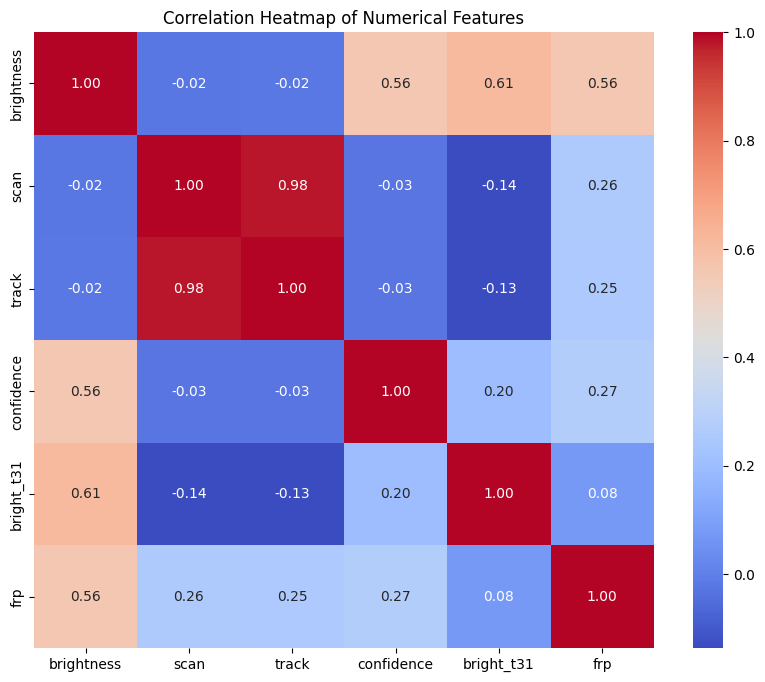

In [16]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded[['brightness', 'scan', 'track', 'confidence', 'bright_t31', 'frp']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [17]:
df_encoded.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,confidence,version,bright_t31,frp,type,daynight_N,satellite_Terra
0,28.0993,96.9983,-1.464544,-0.510086,-0.261043,2021-01-01,409,-1.104583,6.03,-1.315940,-0.236024,0,False,True
1,30.0420,79.6492,-1.549367,-0.034455,0.234147,2021-01-01,547,-1.489933,6.03,-1.943776,-0.231087,0,False,True
2,30.0879,78.8579,-1.662463,-0.192999,-0.261043,2021-01-01,547,-3.086384,6.03,-2.052440,-0.275522,0,False,True
3,30.0408,80.0501,-1.535230,0.124089,0.234147,2021-01-01,547,-0.994483,6.03,-1.907555,-0.210104,0,False,True
4,30.6565,78.9668,-1.612983,-0.192999,-0.261043,2021-01-01,547,-1.159633,6.03,-1.919628,-0.231087,0,False,True


In [18]:
df_encoded.type.value_counts()


,count
type,
0,257625
2,13550
3,42


In [23]:
features = ['brightness', 'scan', 'track', 'confidence', 'bright_t31', 'frp']
target = 'type'

X = df_encoded[features]
Y = df_encoded[target]

In [20]:
X

,brightness,scan,track,confidence,bright_t31,frp
0,-1.464544,-0.510086,-0.261043,-1.104583,-1.315940,-0.236024
1,-1.549367,-0.034455,0.234147,-1.489933,-1.943776,-0.231087
2,-1.662463,-0.192999,-0.261043,-3.086384,-2.052440,-0.275522
3,-1.535230,0.124089,0.234147,-0.994483,-1.907555,-0.210104
4,-1.612983,-0.192999,-0.261043,-1.159633,-1.919628,-0.231087
...,...,...,...,...,...,...
271212,-1.393859,1.392439,1.719720,-0.333883,-1.726448,-0.055816
271213,-1.379722,1.868071,1.719720,-0.278833,-1.762670,0.021945
271214,-1.217145,0.758264,0.729338,0.216617,-1.122760,-0.117531
271215,-0.969746,-0.668630,-0.756234,0.822168,-1.303867,-0.216275


In [24]:
Y

,type
0,0
1,0
2,0
3,0
4,0
...,...
271212,0
271213,0
271214,2
271215,2


In [25]:
!pip install -U imbalanced-learn
from imblearn.over_sampling import SMOTE

In [26]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Distribution of target variable after SMOTE:")
print(y_resampled.value_counts())

Distribution of target variable after SMOTE:
type
0    257625
2    257625
3    257625
Name: count, dtype: int64


Use SMOTE to balance the classes in our dataset


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.25, random_state=42, stratify=y_resampled)

The Data will be splitted into training and testing phase in general it may be 70 and 30 ratio for distribution.

In [28]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (579656, 6)
Shape of X_test: (193219, 6)
Shape of y_train: (579656,)
Shape of y_test: (193219,)


In [31]:
loreg = LogisticRegression(max_iter=300)
loreg.fit(X_train,y_train)
loreg_pred = loreg.predict(X_test)
score = accuracy_score(y_test,loreg_pred)
cr = classification_report(y_test,loreg_pred)

print("Logistic Regression")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

Logistic Regression
Accuracy Score value: 0.5888
              precision    recall  f1-score   support

           0       0.66      0.59      0.62     64406
           2       0.50      0.56      0.53     64406
           3       0.63      0.62      0.62     64407

    accuracy                           0.59    193219
   macro avg       0.59      0.59      0.59    193219
weighted avg       0.59      0.59      0.59    193219



Logistic Regression

In [32]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train,y_train)
dtc_pred = dtc.predict(X_test)
score = accuracy_score(y_test,dtc_pred)
cr = classification_report(y_test,dtc_pred)

print("Decision Tree")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

Decision Tree
Accuracy Score value: 0.9440
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     64406
           2       0.91      0.93      0.92     64406
           3       1.00      1.00      1.00     64407

    accuracy                           0.94    193219
   macro avg       0.94      0.94      0.94    193219
weighted avg       0.94      0.94      0.94    193219



DecisionTree Classifier

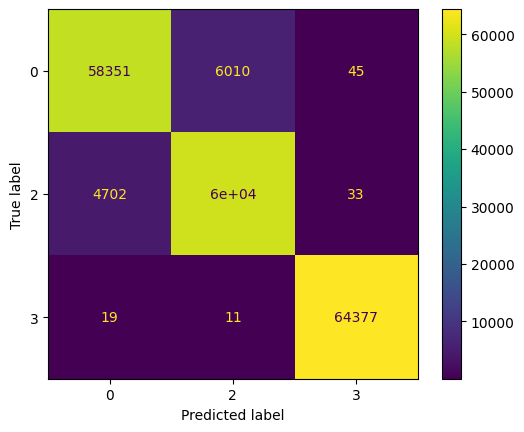

In [33]:
dt_cm = ConfusionMatrixDisplay.from_estimator(dtc, X_test, y_test)

In [34]:
rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)
rfc_pred = rfc.predict(X_test)
score = accuracy_score(y_test,rfc_pred)
cr = classification_report(y_test,rfc_pred)

print("Random Forest")
print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

Random Forest
Accuracy Score value: 0.9696
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     64406
           2       0.95      0.96      0.95     64406
           3       1.00      1.00      1.00     64407

    accuracy                           0.97    193219
   macro avg       0.97      0.97      0.97    193219
weighted avg       0.97      0.97      0.97    193219



RandomForest Classifier


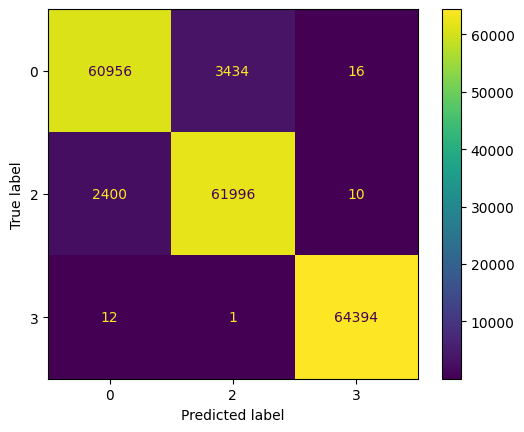

In [35]:
rf_cm = ConfusionMatrixDisplay.from_estimator(rfc, X_test, y_test)

In [36]:
knnc = KNeighborsClassifier()
knnc.fit(X_train,y_train)
knn_pred = knnc.predict(X_test)
score = accuracy_score(y_test,knn_pred)
cr = classification_report(y_test,knn_pred)

print ("Accuracy Score value: {:.4f}".format(score))
print (cr)

Accuracy Score value: 0.9234
              precision    recall  f1-score   support

           0       0.97      0.80      0.87     64406
           2       0.83      0.97      0.90     64406
           3       1.00      1.00      1.00     64407

    accuracy                           0.92    193219
   macro avg       0.93      0.92      0.92    193219
weighted avg       0.93      0.92      0.92    193219



KNeighbors Classifier


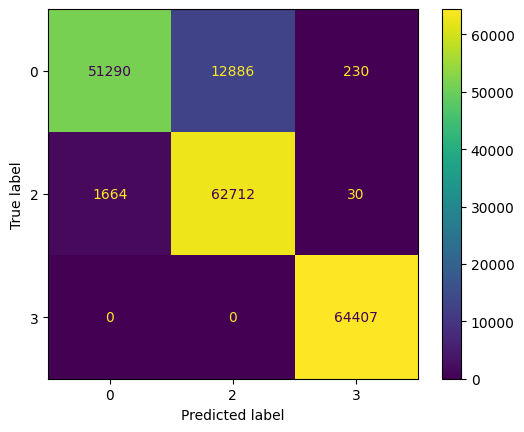

In [37]:
knn_cm = ConfusionMatrixDisplay.from_estimator(knnc, X_test, y_test)

In [38]:
model_accuracies = {
    "Logistic Regression": accuracy_score(y_test, loreg_pred),
    "Decision Tree": accuracy_score(y_test, dtc_pred),
    "Random Forest": accuracy_score(y_test, rfc_pred),
    "KNeighbors Classifier": accuracy_score(y_test, knn_pred)
}

best_model_name = max(model_accuracies, key=model_accuracies.get)
best_model_accuracy = model_accuracies[best_model_name]

print("Model Accuracies:")
for model, accuracy in model_accuracies.items():
    print(f"{model}: {accuracy:.4f}")

print(f"\nBest Model: {best_model_name} with Accuracy: {best_model_accuracy:.4f}")

Model Accuracies:
Logistic Regression: 0.5888
Decision Tree: 0.9440
Random Forest: 0.9696
KNeighbors Classifier: 0.9234

Best Model: Random Forest with Accuracy: 0.9696


Calculating the accuracy for each model, identify the best-performing model, and displaying the bes model.


In [39]:
import joblib

best_model = rfc

joblib.dump(best_model, 'best_fire_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Best model and scaler saved successfully.")

Best model and scaler saved successfully.
